# Portfolio Metrics Extraction Review

Review accepted metrics and extraction errors from the pipeline.

**Data path:** Reads from `../output/` (`metrics.csv`, `extraction_errors.csv`, `metrics_wide.csv`). The repo includes a committed snapshot for API-free review.

In [1]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../output")

metrics_path = DATA_DIR / "metrics.csv"
errors_path = DATA_DIR / "extraction_errors.csv"


def format_number(value):
    if pd.isna(value):
        return ""
    if isinstance(value, (int, float)):
        number = float(value)
        if number == int(number):
            return str(int(number))
        return f"{number:.10f}".rstrip("0").rstrip(".")
    return value


def show_table(df, numeric_cols=None):
    """Render a dataframe or series with blank cells instead of NaN."""
    styler = df.style.format(na_rep="")

    if isinstance(df, pd.Series):
        if pd.api.types.is_numeric_dtype(df):
            styler = styler.format(format_number)
        return styler

    cols = numeric_cols
    if cols is None:
        cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    for col in cols:
        if col in df.columns:
            styler = styler.format(format_number, subset=[col])
    return styler


if not metrics_path.exists():
    raise FileNotFoundError(
        f"Missing {metrics_path}. Run: python -m src.pipeline run --input data/raw --output-dir output"
    )

metrics = pd.read_csv(metrics_path)
errors = (
    pd.read_csv(errors_path)
    if errors_path.exists()
    else pd.DataFrame(columns=["status", "confidence"])
)
print(f"Using {DATA_DIR} ({len(metrics)} accepted metrics)")

show_table(metrics.head())

Using ../output (212 accepted metrics)


,company_short_name,company_full_name,report_date,year,quarter,period_type,metric_name,metric_label,value,unit,scale,currency,source_file,source_page,confidence,raw_text
0,Apex Freight,Apex Freight Solutions Inc.,,2025,Q2,quarter,other,Completed Shipments,1.28,count,millions,,ApexFreight_Q2_2025.pdf,1,0.95,Completed Shipments 1.28M
1,Apex Freight,Apex Freight Solutions Inc.,,2025,Q2,quarter,other,Active Shippers,3460,count,ones,,ApexFreight_Q2_2025.pdf,1,0.95,"Active Shippers 3,460"
2,Apex Freight,Apex Freight Solutions Inc.,,2025,Q2,quarter,other,Active Carriers,7900,count,ones,,ApexFreight_Q2_2025.pdf,1,0.95,"Active Carriers 7,900"
3,Apex Freight,Apex Freight Solutions Inc.,,2025,Q2,quarter,other,On-Time Delivery Rate,96.1,percentage,ones,,ApexFreight_Q2_2025.pdf,1,0.95,On-Time Delivery Rate 96.1%
4,Apex Freight,Apex Freight Solutions Inc.,,2025,Q2,quarter,other,Average Take Rate,11.2,percentage,ones,,ApexFreight_Q2_2025.pdf,1,0.95,Average Take Rate 11.2%


## Accepted metrics

In [2]:
display_cols = [
    c for c in [
        "company_short_name", "normalized_company", "company",
        "company_full_name", "year", "quarter", "period_type",
        "metric_name", "metric", "metric_label", "raw_label",
        "value", "unit", "scale", "confidence", "source_file", "source_page", "page",
    ]
    if c in metrics.columns
]
show_table(metrics[display_cols].head(20))

,company_short_name,company_full_name,year,quarter,period_type,metric_name,metric_label,value,unit,scale,confidence,source_file,source_page
0,Apex Freight,Apex Freight Solutions Inc.,2025,Q2,quarter,other,Completed Shipments,1.28,count,millions,0.95,ApexFreight_Q2_2025.pdf,1
1,Apex Freight,Apex Freight Solutions Inc.,2025,Q2,quarter,other,Active Shippers,3460,count,ones,0.95,ApexFreight_Q2_2025.pdf,1
2,Apex Freight,Apex Freight Solutions Inc.,2025,Q2,quarter,other,Active Carriers,7900,count,ones,0.95,ApexFreight_Q2_2025.pdf,1
3,Apex Freight,Apex Freight Solutions Inc.,2025,Q2,quarter,other,On-Time Delivery Rate,96.1,percentage,ones,0.95,ApexFreight_Q2_2025.pdf,1
4,Apex Freight,Apex Freight Solutions Inc.,2025,Q2,quarter,other,Average Take Rate,11.2,percentage,ones,0.95,ApexFreight_Q2_2025.pdf,1
5,Apex Freight,Apex Freight Solutions Inc.,2025,Q2,quarter,revenue,Recognized Revenue (transaction),8.6,currency,millions,0.95,ApexFreight_Q2_2025.pdf,1
6,Apex Freight,Apex Freight Solutions Inc.,2025,Q2,quarter,revenue,SaaS Tool Fee Revenue,0.7,currency,millions,0.95,ApexFreight_Q2_2025.pdf,1
7,Apex Freight,Apex Freight Solutions Inc.,2025,Q2,quarter,revenue,Total Recognized Revenue,9.3,currency,millions,0.95,ApexFreight_Q2_2025.pdf,1
8,Apex Freight,Apex Freight Solutions Inc.,2025,Q2,quarter,gross_margin,Gross Margin,54,percentage,ones,0.95,ApexFreight_Q2_2025.pdf,1
9,Apex Freight,Apex Freight Solutions Inc.,2025,Q2,quarter,other,Marketing Spend as % of Revenue,16,percentage,ones,0.95,ApexFreight_Q2_2025.pdf,1


## Metric label mapping

In [3]:
metric_col = "metric_name" if "metric_name" in metrics.columns else "metric"
label_col = "metric_label" if "metric_label" in metrics.columns else "raw_label"

if label_col not in metrics.columns:
    print("No metric label column available.")
else:
    label_mapping = (
        metrics.groupby([metric_col, label_col], dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values([metric_col, "count"], ascending=[True, False])
    )
    show_table(label_mapping)

## Pivot by company and period

In [4]:
company_col = "company_short_name" if "company_short_name" in metrics.columns else "normalized_company"
metric_col = "metric_name" if "metric_name" in metrics.columns else "metric"

pivot = metrics.pivot_table(
    index=[company_col, "year", "quarter"],
    columns=metric_col,
    values="value",
    aggfunc="first",
)
show_table(pivot)

## Time series

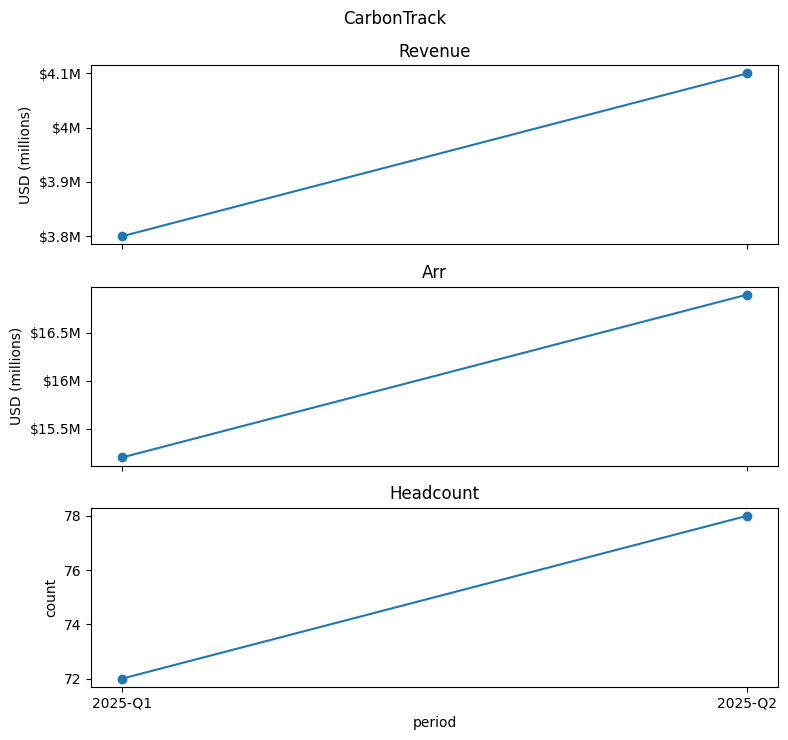

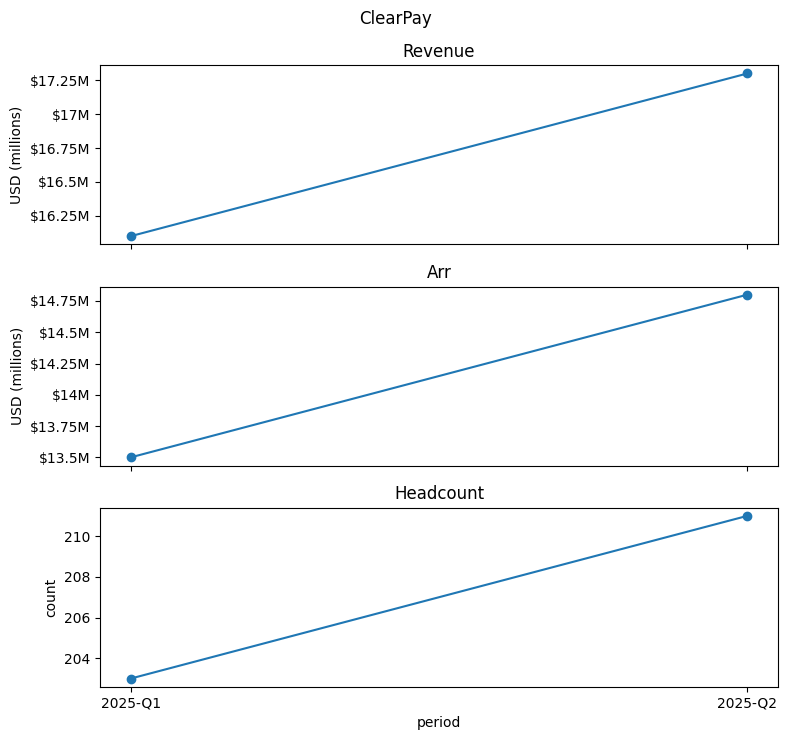

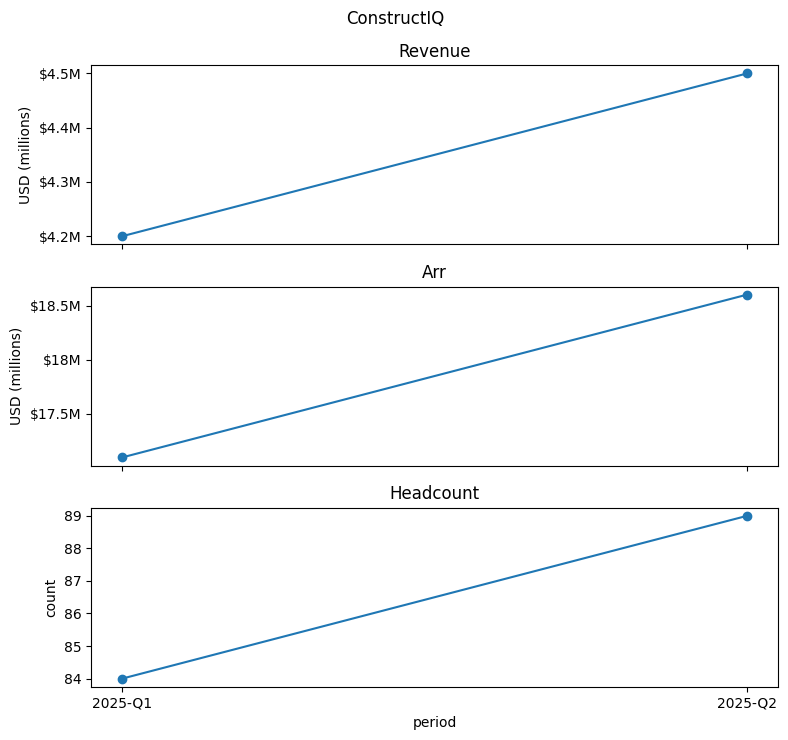

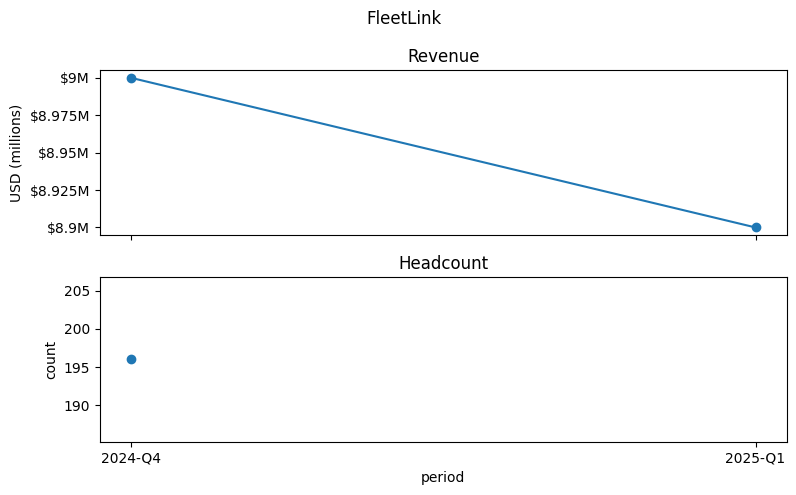

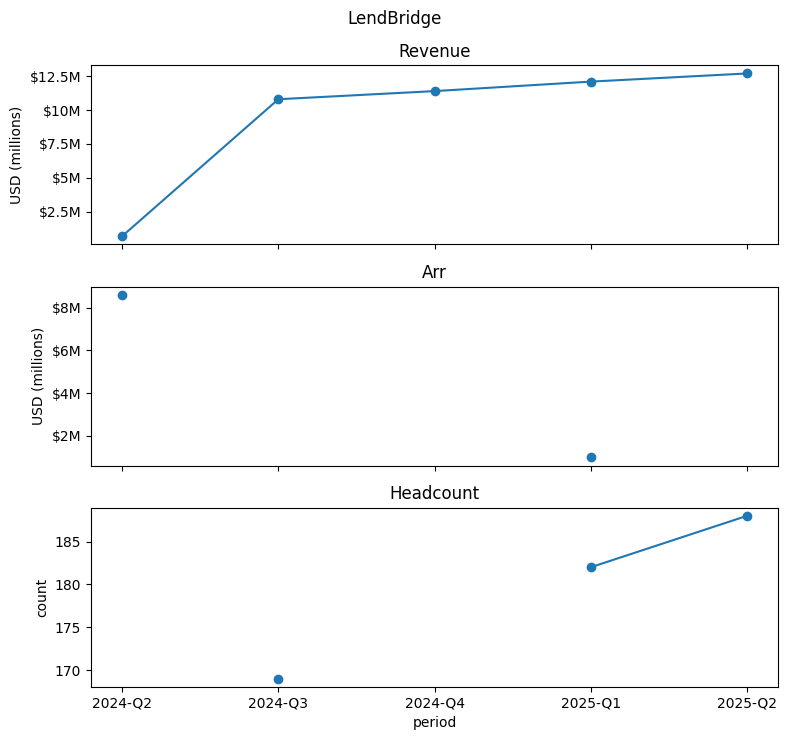

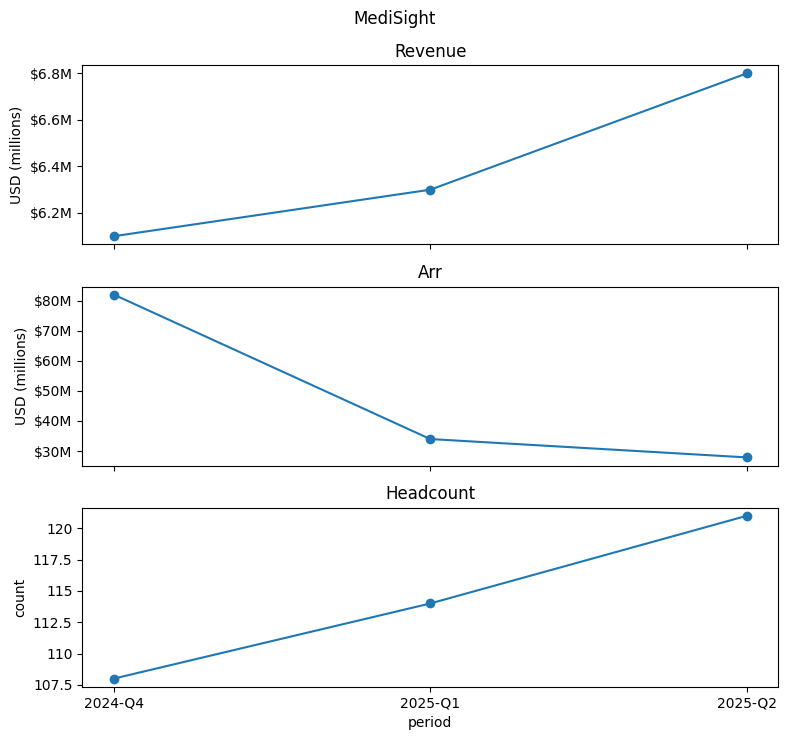

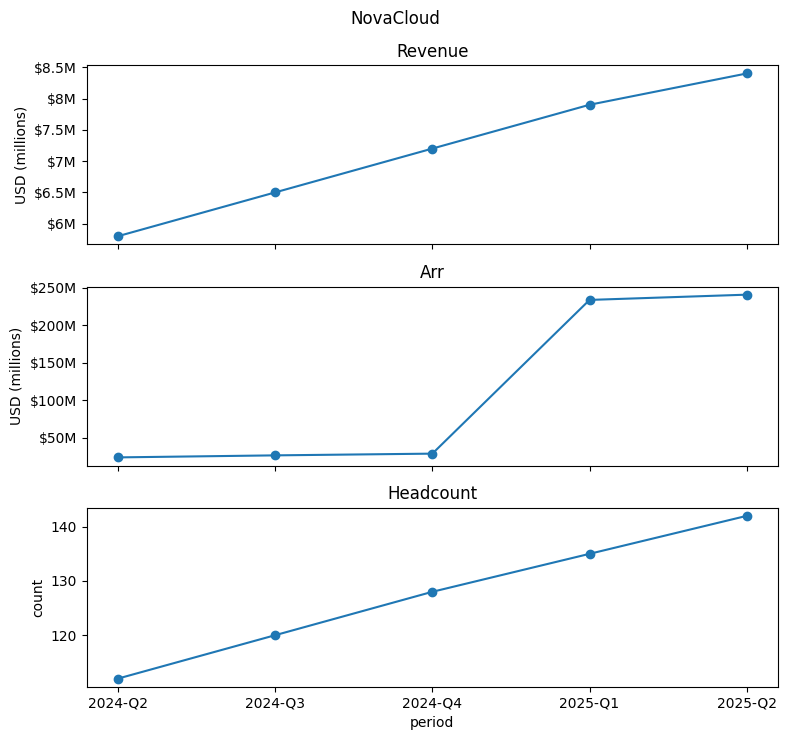

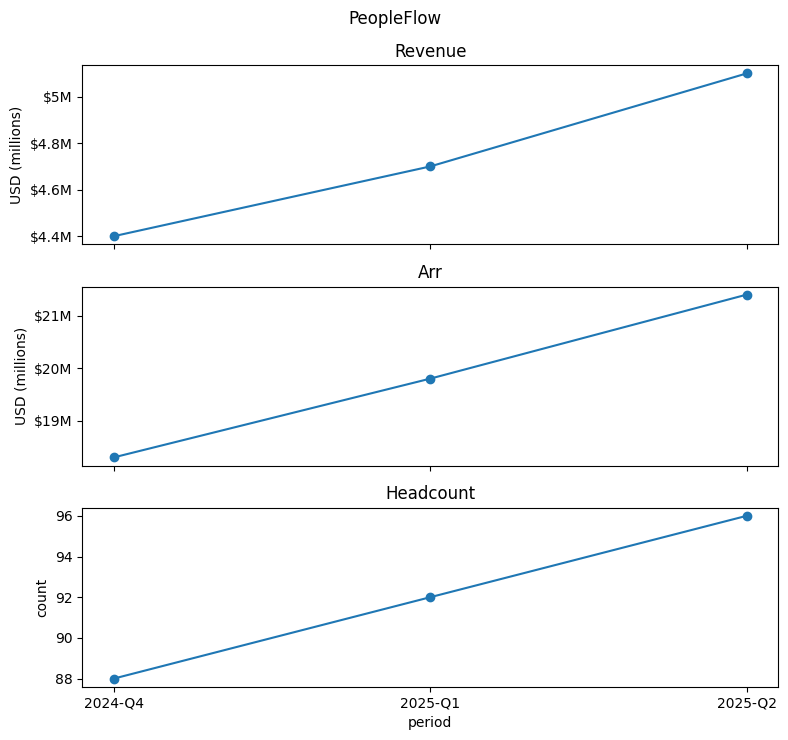

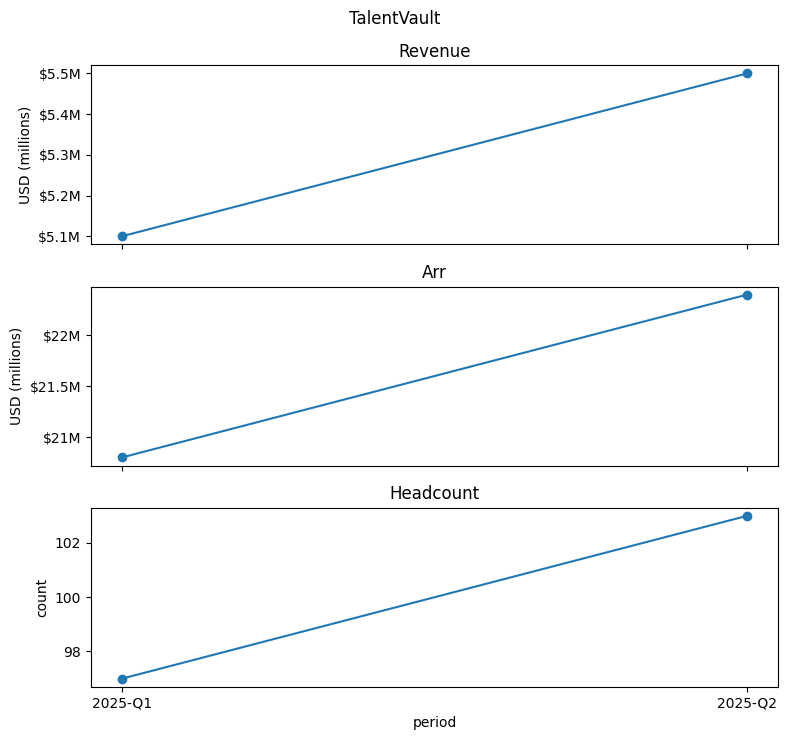

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

wide_path = DATA_DIR / "metrics_wide.csv"
company_col = "company_short_name" if "company_short_name" in metrics.columns else "normalized_company"
metric_col = "metric_name" if "metric_name" in metrics.columns else "metric"
TIME_SERIES_METRICS = ["revenue", "arr", "headcount"]
QUARTER_ORDER = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
CURRENCY_SYMBOLS = {"USD": "$", "GBP": "�", "EUR": "�", "CAD": "C$"}
SCALE_SUFFIX = {"thousands": "K", "millions": "M", "billions": "B"}


def metric_format_info(metric_name):
    subset = metrics[metrics[metric_col] == metric_name]
    if subset.empty:
        return {"unit": "unknown", "scale": "unknown", "currency": None}

    unit = subset["unit"].mode(dropna=True).iloc[0] if subset["unit"].notna().any() else "unknown"
    scale = subset["scale"].mode(dropna=True).iloc[0] if subset["scale"].notna().any() else "unknown"
    currency = subset["currency"].dropna().mode().iloc[0] if subset["currency"].notna().any() else None
    return {"unit": unit, "scale": scale, "currency": currency}


def metric_ylabel(metric_name, info):
    unit, scale, currency = info["unit"], info["scale"], info["currency"]
    if unit == "percentage":
        return "%"
    if unit == "currency":
        currency_code = currency or "USD"
        if scale in ("millions", "thousands", "billions"):
            return f"{currency_code} ({scale})"
        return currency_code
    if unit == "count":
        if scale in ("thousands", "millions", "billions"):
            return f"count ({scale})"
        return "count"
    return metric_name.replace("_", " ").title()


def format_axis_tick(value, info):
    unit, scale, currency = info["unit"], info["scale"], info["currency"]
    symbol = CURRENCY_SYMBOLS.get(currency or "USD", "$")
    suffix = SCALE_SUFFIX.get(scale, "")

    if unit == "percentage":
        return f"{value:g}%"
    if unit == "currency":
        return f"{symbol}{value:g}{suffix}" if suffix else f"{symbol}{value:g}"
    if unit == "count":
        if suffix:
            return f"{value:g}{suffix}"
        if float(value).is_integer():
            return str(int(value))
        return f"{value:g}"
    return f"{value:g}"


def apply_metric_axis(ax, metric_name):
    info = metric_format_info(metric_name)
    ax.set_ylabel(metric_ylabel(metric_name, info))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _pos: format_axis_tick(value, info)))


if not wide_path.exists():
    print("No metrics_wide.csv found.")
else:
    wide = pd.read_csv(wide_path)
    wide["period"] = wide["year"].astype(str) + "-" + wide["quarter"]
    wide["period_sort"] = wide["year"] * 10 + wide["quarter"].map(QUARTER_ORDER)

    multi_period = wide.groupby(company_col).filter(lambda group: group["period"].nunique() > 1)
    available_metrics = [m for m in TIME_SERIES_METRICS if m in wide.columns]

    if multi_period.empty:
        print("No companies with multiple periods for time series.")
    elif not available_metrics:
        print("No time-series metrics available in metrics_wide.csv.")
    else:
        for company, group in multi_period.groupby(company_col):
            plot_data = group.sort_values("period_sort")
            company_metrics = [
                metric for metric in available_metrics if plot_data[metric].notna().any()
            ]
            if not company_metrics:
                continue

            fig, axes = plt.subplots(
                len(company_metrics),
                1,
                figsize=(8, 2.5 * len(company_metrics)),
                sharex=True,
            )
            if len(company_metrics) == 1:
                axes = [axes]

            fig.suptitle(company)
            for ax, metric in zip(axes, company_metrics):
                series = plot_data[["period", metric]].dropna(subset=[metric])
                ax.plot(series["period"], series[metric], marker="o")
                ax.set_title(metric.replace("_", " ").title())
                apply_metric_axis(ax, metric)

            axes[-1].set_xlabel("period")
            plt.tight_layout()
            plt.show()

## Rejected metrics

In [6]:
if not errors.empty and "status" in errors.columns:
    show_table(errors.sort_values(["status", "confidence"], na_position="last").head(20))
else:
    print("No extraction errors file (legacy sample data has no errors CSV).")

## Error status counts

In [7]:
if not errors.empty and "status" in errors.columns:
    errors["status"].value_counts()
else:
    print("No error statuses to summarize.")